### Importing All Required Libraries

In [44]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

### Loading & Resizing the Image

In [45]:
image = cv2.imread("pexels-alexgtacar-745150-1592384.jpg", cv2.IMREAD_GRAYSCALE)
resized_image = cv2.resize(image, (500,500))
resized_image2 = resized_image.copy()


### Gaussian Blur Before Laplacian

In [46]:
g_blur = cv2.GaussianBlur(resized_image, (5, 5), 1.4)  # image, kernel size, sigma

CV2 Bult-in Laplacian

In [47]:
laplacian_edges = cv2.Laplacian(g_blur, -1, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)

### Plots

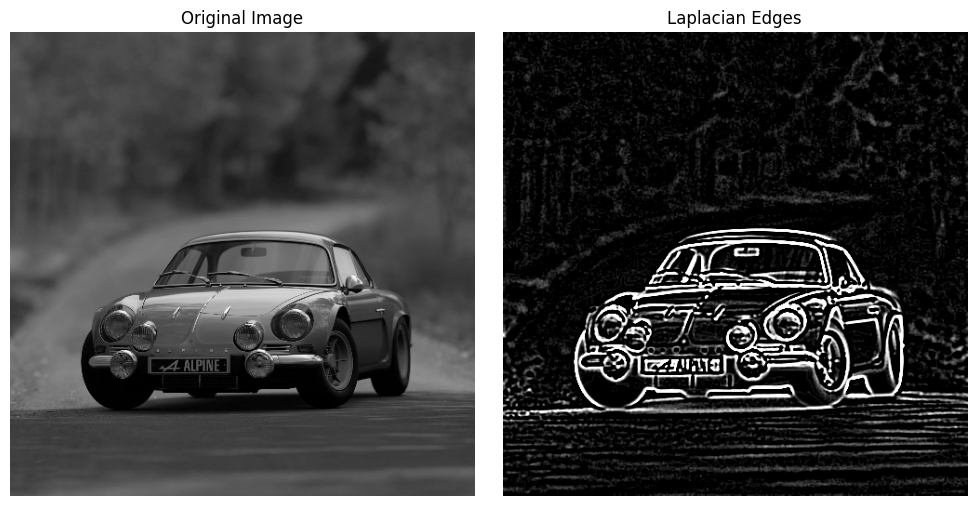

In [48]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(resized_image2, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(laplacian_edges, cmap='gray')
plt.title('Laplacian Edges')
plt.axis('off')
plt.tight_layout()
plt.show()

### Manual Laplacian Kernels(4-Connected $ 8-Connected)

In [49]:
pos4 = np.array([[0,  1, 0],
                 [1, -4, 1],
                 [0,  1, 0]], dtype=np.float32)
 
neg4 = np.array([[ 0, -1,  0],
                 [-1,  4, -1],
                 [ 0, -1,  0]], dtype=np.float32)
 
pos8 = np.array([[1,  1, 1],
                 [1, -8, 1],
                 [1,  1, 1]], dtype=np.float32)
 
neg8 = np.array([[-1, -1, -1],
                 [-1,  8, -1],
                 [-1, -1, -1]], dtype=np.float32)

In [50]:
lap_pos4 = cv2.filter2D(resized_image, -1, pos4)  # image, depth(-1=same as input), kernel
lap_neg4 = cv2.filter2D(resized_image, -1, neg4)
lap_pos8 = cv2.filter2D(resized_image, -1, pos8)
lap_neg8 = cv2.filter2D(resized_image, -1, neg8)

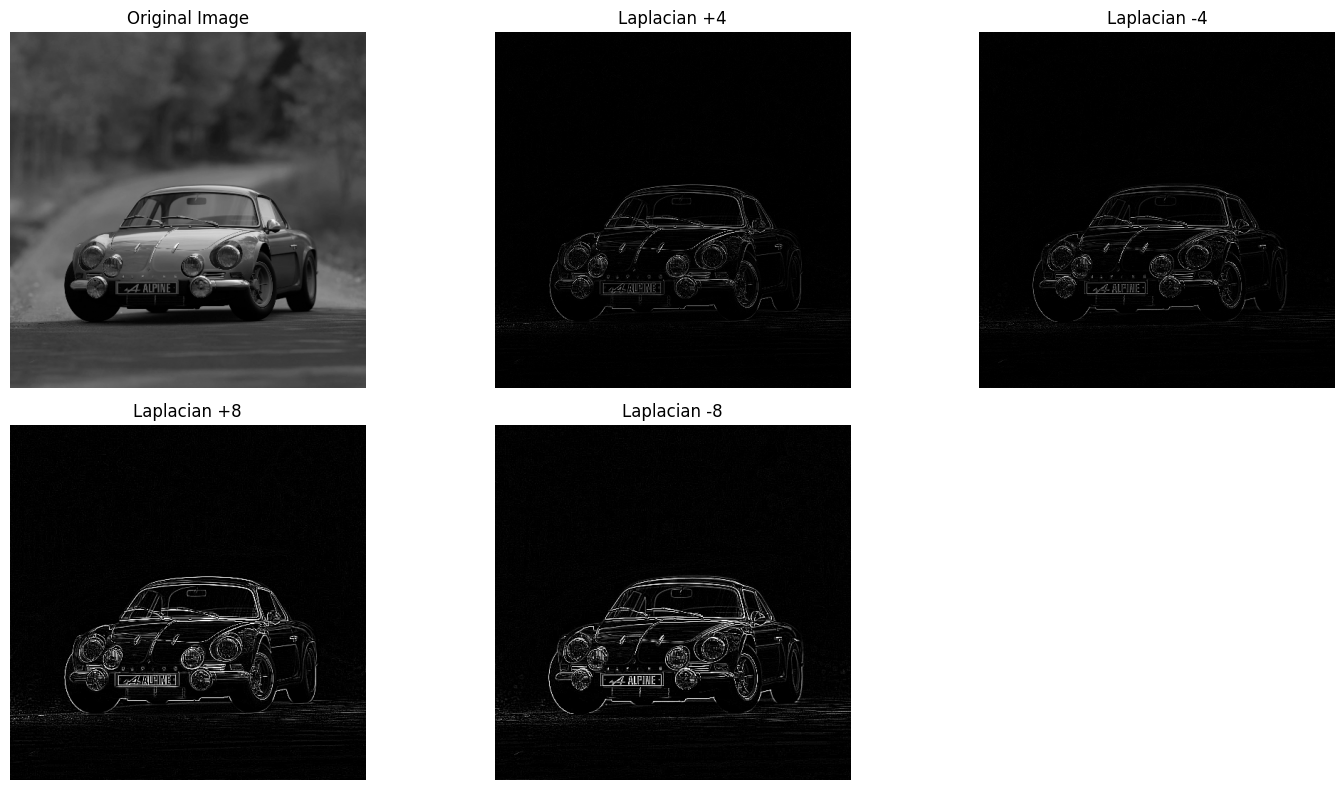

In [51]:
titles = ['Original Image', 'Laplacian +4', 'Laplacian -4', 'Laplacian +8', 'Laplacian -8']
images = [resized_image, lap_pos4, lap_neg4, lap_pos8, lap_neg8]
 
plt.figure(figsize=(15, 8))
for i in range(5):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Task: Different Output Depth Types

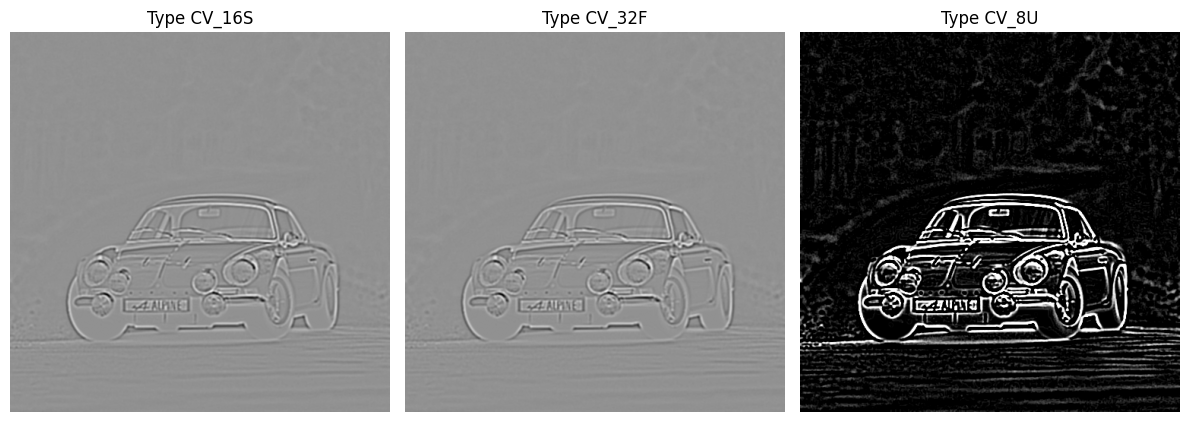

In [52]:
image16s = cv2.Laplacian(g_blur, cv2.CV_16S, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)
image32f = cv2.Laplacian(g_blur, cv2.CV_32F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)
image8u  = cv2.Laplacian(g_blur, cv2.CV_8U,  ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)
 
plt.figure(figsize=(12, 5))
plt.subplot(131); plt.imshow(image16s, cmap='gray'); plt.title('Type CV_16S'); plt.axis('off')
plt.subplot(132); plt.imshow(image32f, cmap='gray'); plt.title('Type CV_32F'); plt.axis('off')
plt.subplot(133); plt.imshow(image8u,  cmap='gray'); plt.title('Type CV_8U');  plt.axis('off')
plt.tight_layout()
plt.show()

### Task: Different Border Types

In [53]:
constant    = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_CONSTANT)   # pad with 0
replicate   = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_REPLICATE)  # repeat last pixel
reflect     = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_REFLECT)    # mirror
reflect_101 = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_REFLECT_101) # mirror without last pixel
isolated    = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_ISOLATED)   # used with ROI

#### BORDER_WRAP — must manually pad (cv2.Laplacian doesn't support it directly)

In [54]:

pad = 2
padded = cv2.copyMakeBorder(g_blur, pad, pad, pad, pad, borderType=cv2.BORDER_WRAP)
wrap = cv2.Laplacian(padded, cv2.CV_64F, ksize=5)
wrap = wrap[pad:-pad, pad:-pad]  # crop back to original size

#### BORDER_TRANSPARENT — simulate by zeroing out border pixels after computation

In [55]:
transparent = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, borderType=cv2.BORDER_REFLECT)
transparent[0:2, :] = 0
transparent[-2:, :] = 0
transparent[:, 0:2] = 0
transparent[:, -2:] = 0

#### BORDER_CONSTANT with value=155

In [56]:
padded_155 = cv2.copyMakeBorder(g_blur, pad, pad, pad, pad, borderType=cv2.BORDER_CONSTANT, value=155)
laplacian_155 = cv2.Laplacian(padded_155, cv2.CV_64F, ksize=5)
laplacian_155 = laplacian_155[pad:-pad, pad:-pad]  # crop back to original size
 

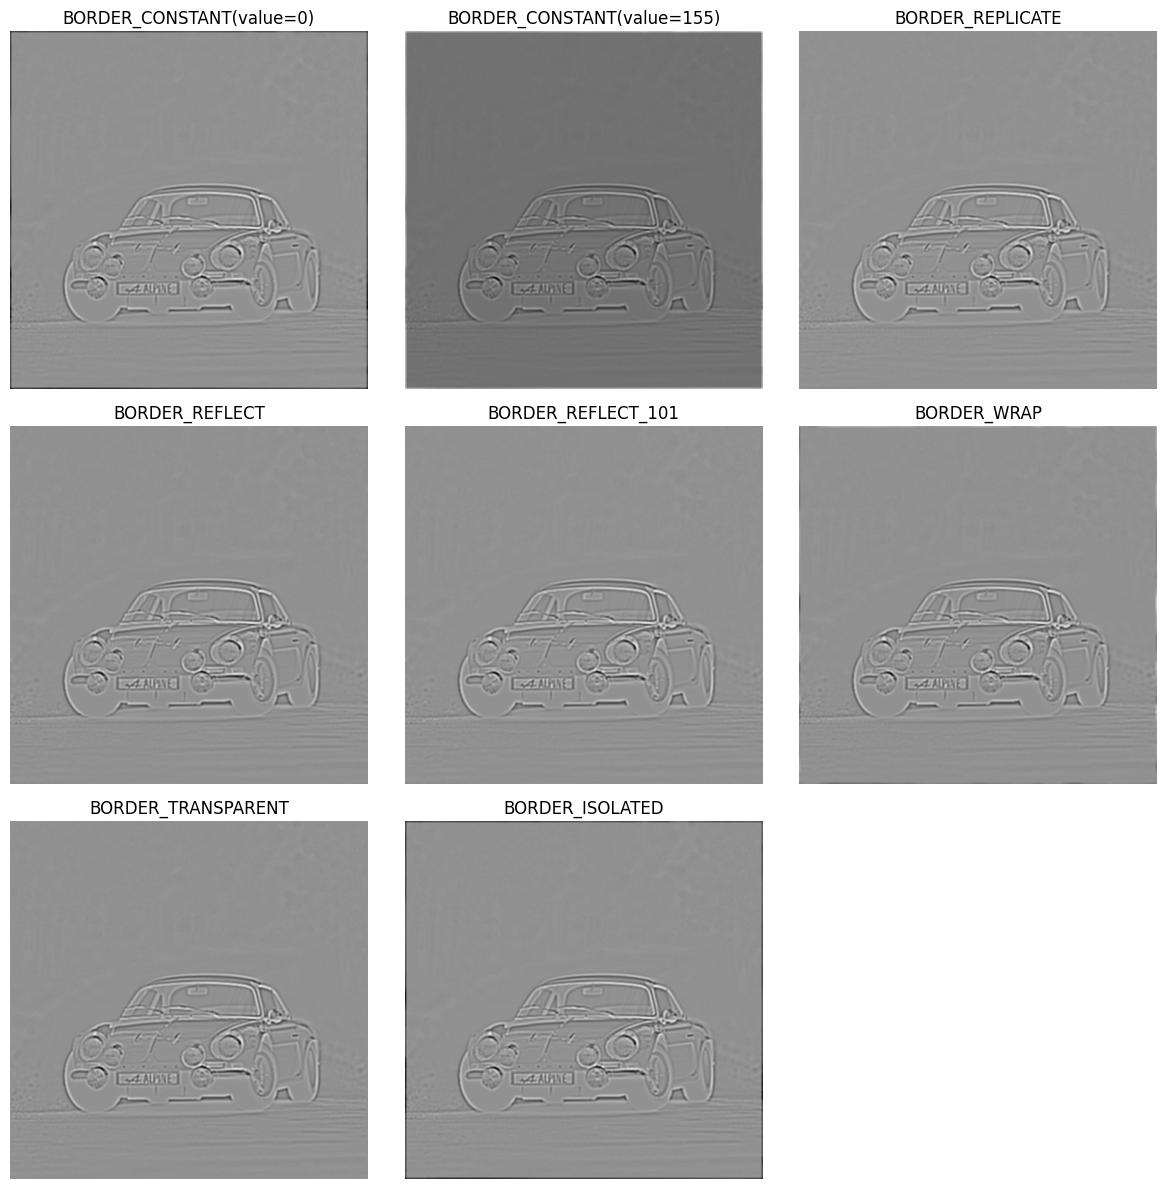

In [57]:
plt.figure(figsize=(12, 12))
border_titles = ['BORDER_CONSTANT(value=0)', 'BORDER_CONSTANT(value=155)', 'BORDER_REPLICATE',
                 'BORDER_REFLECT', 'BORDER_REFLECT_101', 'BORDER_WRAP', 'BORDER_TRANSPARENT', 'BORDER_ISOLATED']
border_images = [constant, laplacian_155, replicate, reflect, reflect_101, wrap, transparent, isolated]
for i in range(8):
    plt.subplot(3, 3, i + 1)
    plt.imshow(border_images[i], cmap='gray')
    plt.title(border_titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()